In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

Prikazati osnovne deskriptivne statistike (prosek, standardna devijacija, kvartili).

In [2]:
data = pd.read_csv('wine.csv')
mean = data.mean()
std = data.std()
quantile = data.quantile()

In [3]:
print(mean)

target                            0.938202
alcohol                          13.000618
malic_acid                        2.336348
ash                               2.366517
alcalinity_of_ash                19.494944
magnesium                        99.741573
total_phenols                     2.295112
flavanoids                        2.029270
nonflavanoid_phenols              0.361854
proanthocyanins                   1.590899
color_intensity                   5.058090
hue                               0.957449
od280/od315_of_diluted_wines      2.611685
proline                         746.893258
dtype: float64


In [4]:
print(std)

target                            0.775035
alcohol                           0.811827
malic_acid                        1.117146
ash                               0.274344
alcalinity_of_ash                 3.339564
magnesium                        14.282484
total_phenols                     0.625851
flavanoids                        0.998859
nonflavanoid_phenols              0.124453
proanthocyanins                   0.572359
color_intensity                   2.318286
hue                               0.228572
od280/od315_of_diluted_wines      0.709990
proline                         314.907474
dtype: float64


In [5]:
print(quantile)

target                            1.000
alcohol                          13.050
malic_acid                        1.865
ash                               2.360
alcalinity_of_ash                19.500
magnesium                        98.000
total_phenols                     2.355
flavanoids                        2.135
nonflavanoid_phenols              0.340
proanthocyanins                   1.555
color_intensity                   4.690
hue                               0.965
od280/od315_of_diluted_wines      2.780
proline                         673.500
Name: 0.5, dtype: float64


Ukoliko ima nedostajućih vrednosti, izbaciti instance koje ih sadrže.

In [6]:
data.isna().any().any()

False

Odrediti elemente van granica (eng. outliers) korišćenjem interkvartilnog raspona. Ukoliko postoje, zameniti ih graničnim vrednostima. 

In [7]:
for col in data.columns:
    if col != "target":
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        data[col] = data[col].clip(lower, upper)

Klasifikovati podatke (ciljna kolona je ‘target’) korišćenjem stabla odlučivanja. 

Da li je potrebno podeliti podatke na trening i test skup? Da li je potrebno primeniti neki vid normalizacije podataka? 

In [8]:
y = data['target']
X = data.drop('target', axis=1)
feature_names = X.columns

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, stratify=y, random_state=67)
# ne treba normalizacija

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)

Prikazati matricu konfuzije, tačnost i F1. Oceniti kvalitet modela.

In [9]:
acc_score = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
f1_sc = f1_score(y_test, y_pred, average='macro')

print(f'Tacnost: {acc_score}')
print(f'F1: {f1_sc}')
print(f'Matrica konfuzije:\n{conf_matrix}')

Tacnost: 0.9111111111111111
F1: 0.9151929158760278
Matrica konfuzije:
[[14  1  0]
 [ 2 15  1]
 [ 0  0 12]]


Obučiti model slučajne šume i uporediti rezultate. 

In [10]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)

acc_rfc = accuracy_score(y_test, y_pred)
conf_rfc = confusion_matrix(y_test, y_pred)
f1_rfc = f1_score(y_test, y_pred, average='macro')

print(f'Tacnost: {acc_rfc}')
print(f'F1: {f1_rfc}')
print(f'Matrica konfuzije:\n{conf_rfc}')

Tacnost: 0.9111111111111111
F1: 0.9151929158760278
Matrica konfuzije:
[[14  1  0]
 [ 2 15  1]
 [ 0  0 12]]


Primenom PCA smanjiti dimenzionalnost podataka na 2. Koji udeo početne varijanse podataka je očuvan? 

In [11]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2)
pca.fit(X_train_scaled)

sum(pca.explained_variance_ratio_)

0.5524965640044432

Tako transformisan skup prikazati grafički korišćenjem scatter plota. Obojiti instance na osnovu predviđene klase. 

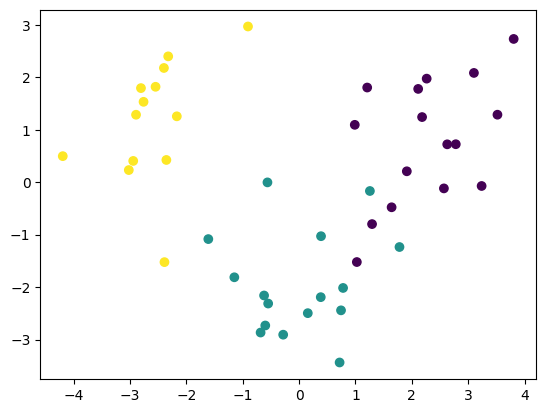

In [12]:
X_test_pca = pca.transform(X_test_scaled)

scatter = plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=y_pred)